# Base Modal Shares 2022 — Revealed Behavior for LRT Capture

Step 2 of the forecast hierarchy: from the observed 2022 modal components,
compute per-OD revealed shares

$$S^{m}_{ij} = \frac{T^{m}_{ij}}{T^{ALL}_{ij}}, \qquad m \in \{\text{car/other},\ \text{bus},\ \text{rail}\}$$

on the 25-area system, and smooth them into a stable behavioral baseline.
The components reproduce the vintage-alignment composition exactly:
CAR/OTHER (`transit/car_other_area_2022.csv`) + bus (`bus/bus_od_area_new_filtered.csv`,
the 2022 RavKav anchor) + rail (`train/train_od_area.csv` × 54.7/69.0). Rail is
heavy rail only.

**Smoothing design.** Raw cell shares are noisy where cell volumes are small, so
each cell is shrunk toward its stratum's volume-weighted share with empirical-Bayes
weight (the same shrinkage form the hybrid pipeline uses):

$$\tilde S^{m}_{ij} = \frac{T^{ALL}_{ij}\,S^{m}_{ij} + k\,\bar S^{m}_{g(ij)}}{T^{ALL}_{ij} + k}$$

which preserves $\sum_m \tilde S^m_{ij} = 1$ exactly. Strata $g(ij)$ combine the
smoothing dimensions available in this data:

- **corridor access class** — both ends in an LRT-corridor area / one end / neither
  (mixed areas 15, 18 count as corridor). At the 25-area resolution this is also
  the station-accessibility proxy: finer access measures need the alignment's
  stop locations, which belong to the LRT-capture step.
- **distance band** — intra-area, <5, 5–10, 10–20, ≥20 km between area centroids
  (TAZ bbox centroids weighted by 2020 population + employment, ITM meters).
- The superzone dimension is already absorbed by the 25-area aggregation itself.
- **Trip purpose is not observable here**: RavKav and rail smartcards carry no
  purpose, and shares must stay consistent with those volume anchors. A
  purpose-profile overlay from the THS survey is a later refinement.

$k = 50$ trips: cells with volumes well above 50 keep their own signal, small
cells inherit the stratum behavior; a k = 20/100 sensitivity is reported.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile

pd.set_option('display.width', 220)
RAIL_FACTOR_2019_2022 = 54.7 / 69.0
K = 50

def load_area(name, areas=None):
    m = pd.read_csv(name, index_col=0)
    m.index = m.index.astype(int); m.columns = m.columns.astype(int)
    if areas is not None:
        m = m.reindex(index=areas, columns=areas, fill_value=0)
    return m

allm = load_area('Output/transit/all_adjusted_area_2022.csv')
AREAS = list(allm.index)
car = load_area('Output/transit/car_other_area_2022.csv', AREAS)
bus = load_area('Output/bus/bus_od_area_new_filtered.csv', AREAS)
rail = load_area('Output/train/train_od_area.csv', AREAS) * RAIL_FACTOR_2019_2022

resid = (car + bus + rail - allm).abs().values.max()
print(f'additivity check |car+bus+rail - all| max = {resid:.2e}  '
      f'(components: car/other {car.values.sum():,.0f}, bus {bus.values.sum():,.0f}, '
      f'rail {rail.values.sum():,.0f}, all {allm.values.sum():,.0f})')
T = car + bus + rail          # exact total, avoids %.6g rounding residue

additivity check |car+bus+rail - all| max = 6.30e-02  (components: car/other 251,684, bus 23,909, rail 763, all 276,355)


In [2]:
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode')
sub = pd.read_excel('Input/Submatrix_tazs.xlsx')
z20 = pd.read_csv('Input/Demographic_Forecast/Zonal_2020.csv',
                  encoding='utf-8', encoding_errors='replace').set_index('TAZ_ID')

r = shapefile.Reader('Input/TAZ_North/TAZ_North.shp')
fld = [f[0] for f in r.fields[1:]]
cent = {}
for sr in r.shapeRecords():
    rec = dict(zip(fld, sr.record))
    b = sr.shape.bbox
    cent[rec['TAZ_NUMBER']] = ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)

rows = []
for a, g in sub.groupby('AggAreaCode'):
    tazs = [t for t in g.TAZ if t in cent]
    w = np.array([z20.POPULATION.get(t, 0) + z20.EMPL_TOT.get(t, 0) for t in tazs], float)
    w = np.where(w.sum() > 0, w, 1.0)
    xy = np.array([cent[t] for t in tazs])
    rows.append({'AggAreaCode': a, 'x': np.average(xy[:, 0], weights=w),
                 'y': np.average(xy[:, 1], weights=w)})
cxy = pd.DataFrame(rows).set_index('AggAreaCode').reindex(AREAS)
assert cxy.notna().all().all()

dist_km = pd.DataFrame(
    np.hypot(cxy.x.values[:, None] - cxy.x.values[None, :],
             cxy.y.values[:, None] - cxy.y.values[None, :]) / 1000,
    index=AREAS, columns=AREAS)

is_corr = legend.IsLRT_Corridor.reindex(AREAS).isin([1, -1])
n_corr = is_corr.values[:, None].astype(int) + is_corr.values[None, :].astype(int)
cls = np.select([n_corr == 2, n_corr == 1], ['both', 'one-end'], 'neither')
band = np.select([np.eye(len(AREAS), dtype=bool), dist_km.values < 5,
                  dist_km.values < 10, dist_km.values < 20],
                 ['intra', '<5km', '5-10km', '10-20km'], '20km+')
strata = pd.DataFrame({'cls': cls.ravel(), 'band': band.ravel(),
                       'T': T.values.ravel(), 'bus': bus.values.ravel(),
                       'rail': rail.values.ravel(), 'car': car.values.ravel()})
strat = strata.groupby(['cls', 'band']).sum()
for m in ['car', 'bus', 'rail']:
    strat[f'S_{m}'] = strat[m] / strat['T']
strat['n_cells'] = strata.groupby(['cls', 'band']).size()
band_order = ['intra', '<5km', '5-10km', '10-20km', '20km+']
strat = strat.reindex(pd.MultiIndex.from_product([['both', 'one-end', 'neither'], band_order],
                                                 names=['cls', 'band'])).dropna(subset=['T'])
print(strat[['n_cells', 'T', 'S_car', 'S_bus', 'S_rail']].round(3).to_string())

                 n_cells          T  S_car  S_bus  S_rail
cls     band                                             
both    intra       20.0  68471.403  0.986  0.014   0.000
        <5km       130.0  22628.801  0.792  0.206   0.002
        5-10km     126.0   9010.682  0.746  0.242   0.012
        10-20km     90.0   2694.316  0.938  0.062   0.000
        20km+       34.0   3193.530  0.573  0.427   0.000
one-end <5km        52.0  29407.458  0.899  0.100   0.000
        5-10km      92.0  13834.960  0.757  0.211   0.032
        10-20km     46.0   4336.402  0.651  0.311   0.037
        20km+       10.0    844.909  0.703  0.297   0.000
neither intra        5.0  93993.142  0.960  0.040   0.000
        <5km        10.0  23512.225  0.898  0.102   0.000
        5-10km      10.0   4427.202  0.794  0.206   0.000


In [3]:
key = pd.MultiIndex.from_arrays([cls.ravel(), band.ravel()])
prior = {m: strat[f'S_{m}'].reindex(key).values.reshape(T.shape) for m in ['car', 'bus', 'rail']}

def smooth(k):
    out = {}
    Tv = T.values
    for m, comp in [('car', car), ('bus', bus), ('rail', rail)]:
        with np.errstate(invalid='ignore'):
            raw = np.where(Tv > 0, comp.values / np.where(Tv > 0, Tv, 1), np.nan)
        out[m] = (np.nan_to_num(raw * Tv) + k * prior[m]) / (Tv + k)
    return out

S_raw = {m: np.where(T.values > 0, c.values / np.where(T.values > 0, T.values, 1), np.nan)
         for m, c in [('car', car), ('bus', bus), ('rail', rail)]}
S = smooth(K)
chk = S['car'] + S['bus'] + S['rail']
print(f'share sums: min {chk.min():.6f} max {chk.max():.6f} | '
      f'zero-volume cells (take stratum prior): {(T.values == 0).sum()} of {T.size}')

os.makedirs('Output/forecast', exist_ok=True)
for m, tag in [('car', 'car_other'), ('bus', 'bus'), ('rail', 'rail')]:
    pd.DataFrame(S[m], index=AREAS, columns=AREAS).round(5)\
      .to_csv(f'Output/forecast/share_{tag}_2022_smoothed.csv')
    pd.DataFrame(S_raw[m], index=AREAS, columns=AREAS).round(5)\
      .to_csv(f'Output/forecast/share_{tag}_2022_raw.csv')
strat.round(4).to_csv('Output/forecast/share_strata_2022.csv')

# sensitivity: how much smoothing moves the transit share, by cell volume
tr_raw = np.where(T.values > 0, (bus.values + rail.values) / np.where(T.values > 0, T.values, 1), np.nan)
for k in [20, 50, 100]:
    Sk = smooth(k)
    d = np.abs((Sk['bus'] + Sk['rail']) - tr_raw)
    big = T.values >= 500
    print(f'k={k:>3}: median |Δ transit share| = {np.nanmedian(d):.4f} all cells, '
          f'{np.nanmedian(d[big]):.4f} in cells ≥500 trips (n={big.sum()})')

share sums: min 1.000000 max 1.000000 | zero-volume cells (take stratum prior): 155 of 625
k= 20: median |Δ transit share| = 0.0323 all cells, 0.0010 in cells ≥500 trips (n=63)
k= 50: median |Δ transit share| = 0.0605 all cells, 0.0025 in cells ≥500 trips (n=63)
k=100: median |Δ transit share| = 0.0918 all cells, 0.0048 in cells ≥500 trips (n=63)


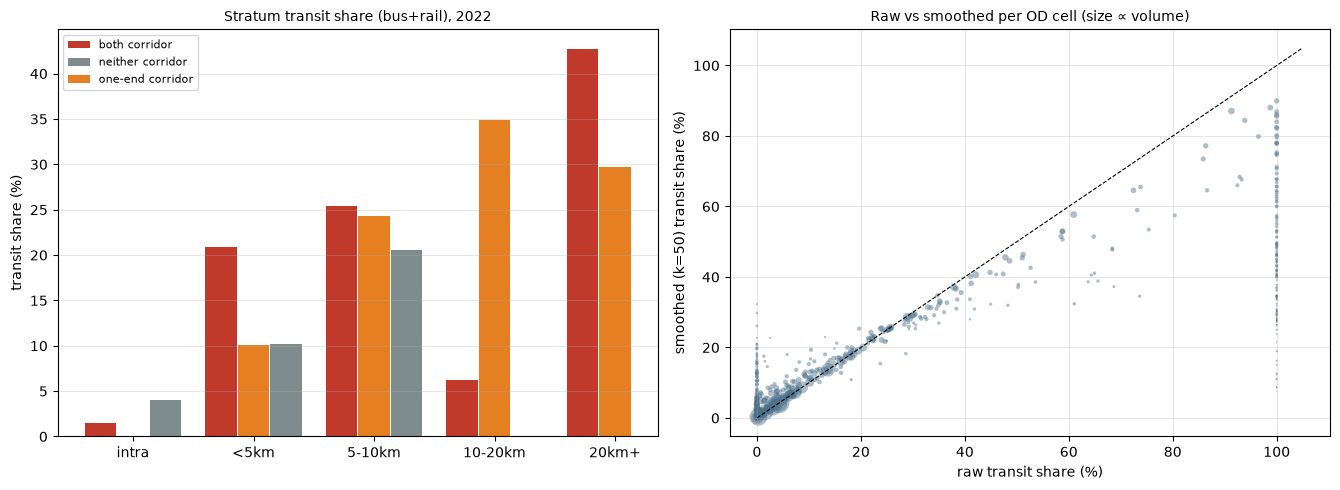

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
ax = axes[0]
plot = strat.reset_index()
colors = {'both': '#c0392b', 'one-end': '#e67e22', 'neither': '#7f8c8d'}
w, off = 0.26, {'both': -0.27, 'one-end': 0.0, 'neither': 0.27}
for c, g in plot.groupby('cls'):
    g = g.set_index('band').reindex(band_order).dropna(subset=['T'])
    x = [band_order.index(b) for b in g.index]
    ax.bar(np.array(x) + off[c], (g.S_bus + g.S_rail) * 100, width=w,
           color=colors[c], label=f'{c} corridor')
ax.set_xticks(range(len(band_order))); ax.set_xticklabels(band_order)
ax.set_ylabel('transit share (%)'); ax.set_title('Stratum transit share (bus+rail), 2022', fontsize=10)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
m = T.values > 0
ax.scatter(np.asarray(tr_raw)[m] * 100, ((S['bus'] + S['rail'])[m]) * 100,
           s=np.sqrt(T.values[m]), alpha=0.45, color='#4a6f8a', edgecolor='none')
lim = max(np.nanmax(tr_raw[m]), (S['bus'] + S['rail'])[m].max()) * 100 * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
ax.set_xlabel('raw transit share (%)'); ax.set_ylabel(f'smoothed (k={K}) transit share (%)')
ax.set_title('Raw vs smoothed per OD cell (size ∝ volume)', fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('Output/figures/mode_share_smoothing_2022.png', dpi=150, bbox_inches='tight')
plt.show()

## Outputs

- `Output/forecast/share_{car_other,bus,rail}_2022_{raw,smoothed}.csv` — per-OD
  revealed shares, raw and EB-smoothed (k = 50), 25×25; smoothed shares sum to 1
  per cell by construction.
- `Output/forecast/share_strata_2022.csv` — the behavioral baseline table:
  volume-weighted modal shares by corridor class × distance band.

These smoothed shares are the **no-build behavioral baseline**: applied to the
four forecast all-modes matrices they give no-build modal demand
$T^{m}_{ij,y} = \tilde S^{m}_{ij} \cdot T^{ALL}_{ij,y}$, and they are the pivot
for the LRT-capture step (LRT ridership = shift applied against these shares,
not against raw noisy cells).